<!-- 

 © Copyright IBM Corporation 2025-2026

 SPDX-License-Identifier: Apache-2.0

 -->



# TerraKit: Climate Data Store search and query



Use the TerraKit Climate Data Store Data Connector to search and query data from [CDS](https://cds.climate.copernicus.eu/datasets/). Available collections include:



 - [ERA5 post-processed daily statistics on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/derived-era5-single-levels-daily-statistics?tab=overview)

 - [CORDEX regional climate model data on single levels](https://cds.climate.copernicus.eu/datasets/projections-cordex-domains-single-levels?tab=overview)



<div class="alert alert-block alert-success">

<b>Install TerraKit</b> For instructions on how to install TerraKit, take a look at the <a href="https://terrastackai.github.io/terrakit/">Welcome</a> page.

</div>

In [10]:
import matplotlib.pyplot as plt

from terrakit import DataConnector

from terrakit.general_utils.plotting import (
    plot_era5_variable,
    plot_era5_variables_comparison,
)

### Create an account

Create an account at [https://cds.climate.copernicus.eu/](https://cds.climate.copernicus.eu/). Once created, find your API  key under the `Profile` section. Each dataset may also require accepting the licence agreement. If this is the case, the first time a request is made, an error will be returned with the url to visit to accept the terms.

### Connect to CDS

In [3]:
data_connector = "climate_data_store"
dc = DataConnector(connector_type=data_connector)
dc.connector.list_collections()

2026-03-24 10:17:08,479 - INFO - Initializing DataConnector with connector type: climate_data_store
2026-03-24 10:17:08,480 - INFO - climate_data_store
2026-03-24 10:17:08,482 - INFO - climate_data_store
2026-03-24 10:17:08,483 - INFO - Listing available collections


['projections-cordex-domains-single-levels',
 'derived-era5-single-levels-daily-statistics']

TerraKit defines a bounding box as a list using the format `[min_lon, min_lat, max_lon, max_lat]`, which is equivalent to `[West, South, East, North]`. Let's do that!

In [4]:
# Small area over Western Europe [min_lon, min_lat, max_lon, max_lat]
bbox = [-10, 40, 5, 50]  # [West, South, East, North]

### Derived ERA5 Single Levels Daily Statistics

Now we can search for data from the Derived ERA5 Single Levels Daily Statistics collection.



The `find_data()` function will search for data and return both a list of unique dates where data is available, but also the raw results from the search.

In [5]:
collection_name = "derived-era5-single-levels-daily-statistics"
date_start = "2024-01-01"
date_end = "2024-01-03"  # 3 days for quick testing

# Variables covering all 4 parameter classes
bands = [
    # Instantaneous
    "2m_temperature",
    "10m_u_component_of_wind",
    "mean_sea_level_pressure",
    # Accumulated
    "total_precipitation",
    "surface_net_solar_radiation",
    "evaporation",
    # Mean rate
    "mean_total_precipitation_rate",
    # Min/Max
    "maximum_2m_temperature_since_previous_post_processing",
    "minimum_2m_temperature_since_previous_post_processing",
]

# Additional query parameters
query_params = {
    "daily_statistic": "daily_mean",
    "time_zone": "utc+00:00",
    "frequency": "1_hourly",
}

Now to query the data, we specify the bands we want to return, plus an (optional) save filename. The `get_data()` function will query the data from the data source and return an **xarray.Dataset** containing all the fetched data. Each variable is a separate data variable with dimensions (time, latitude, longitude), and each variable includes a `stepType` attribute indicating its parameter class.

**Important**: The method now returns `xarray.Dataset` (not `DataArray`) to preserve parameter class (stepType) information for each variable.

Optionally, if `save_file=` is provided as an argument to `get_data()`, individual NetCDF files will be saved for each date with the naming pattern: {save_file}_{date}.nc (e.g., 'output_2024-01-01.nc', 'output_2024-01-02.nc'). Each file contains all requested bands for that specific date.

In [6]:
save_filestem = f"./tmp_download/{data_connector}_{collection_name}"

ds = dc.connector.get_data(
    data_collection_name=collection_name,
    date_start=date_start,
    date_end=date_end,
    bbox=bbox,
    bands=bands,
    query_params=query_params,
    save_file=f"{save_filestem}.nc",
)

# Note: get_data() now returns an xarray.Dataset (not DataArray)
# Each variable is a data variable with its own stepType attribute
print(f"Downloaded {len(ds.data_vars)} variables: {list(ds.data_vars)}")
print(f"Time steps: {len(ds.time)}")
print(
    f"Spatial dimensions: {len(ds.latitude)} latitudes x {len(ds.longitude)} longitudes"
)

2026-03-24 10:17:21,650 - INFO - Submitting CDS request for derived-era5-single-levels-daily-statistics
2026-03-24 10:17:21,650 - INFO - Date range: 2024-01-01 to 2024-01-03 (3 days)
2026-03-24 10:17:21,650 - INFO - Area: 1306839.4 km²
2026-03-24 10:17:21,651 - INFO - Variables: 9
2026-03-24 10:17:21,651 - INFO - Estimated size: ~352.85 MB
2026-03-24 10:17:21,652 - INFO - Estimated time: ~72.6 minutes


1940-01-01 00:00:00 2026-02-04 00:00:00


2026-03-24 10:17:22,313 - INFO - Request submitted to CDS queue. Please wait...
2026-03-24 10:17:22,659 INFO Request ID is 60d9bd0d-3801-4961-91a8-1b873115acb3
2026-03-24 10:17:22,659 - INFO - Request ID is 60d9bd0d-3801-4961-91a8-1b873115acb3
2026-03-24 10:17:22,727 INFO status has been updated to accepted
2026-03-24 10:17:22,727 - INFO - status has been updated to accepted
2026-03-24 10:17:44,099 INFO status has been updated to successful
2026-03-24 10:17:44,099 - INFO - status has been updated to successful
2026-03-24 10:17:44,710 - INFO - Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-03-23/b19ed09eb8879c91a00e93fbe6363127.zip


b19ed09eb8879c91a00e93fbe6363127.zip:   0%|          | 0.00/383k [00:00<?, ?B/s]

2026-03-24 10:17:45,495 - INFO - ✓ Download complete: cds_derived-era5-single-levels-daily-statistics_20260324_101722.zip
2026-03-24 10:17:45,497 - INFO - Actual time: 0.4 minutes


[PosixPath('temp_netcdf/minimum_2m_temperature_since_previous_post_processing_0_daily-mean.nc'), PosixPath('temp_netcdf/2m_temperature_stream-oper_daily-mean.nc'), PosixPath('temp_netcdf/10m_u_component_of_wind_0_daily-mean.nc'), PosixPath('temp_netcdf/mean_sea_level_pressure_0_daily-mean.nc'), PosixPath('temp_netcdf/mean_total_precipitation_rate_0_daily-mean.nc'), PosixPath('temp_netcdf/surface_net_solar_radiation_0_daily-mean.nc'), PosixPath('temp_netcdf/maximum_2m_temperature_since_previous_post_processing_0_daily-mean.nc'), PosixPath('temp_netcdf/total_precipitation_0_daily-mean.nc'), PosixPath('temp_netcdf/evaporation_0_daily-mean.nc')]
9


2026-03-24 10:17:46,029 - INFO - Saved tmp_download/climate_data_store_derived-era5-single-levels-daily-statistics_2024-01-01.nc
2026-03-24 10:17:46,067 - INFO - Saved tmp_download/climate_data_store_derived-era5-single-levels-daily-statistics_2024-01-02.nc
2026-03-24 10:17:46,106 - INFO - Saved tmp_download/climate_data_store_derived-era5-single-levels-daily-statistics_2024-01-03.nc
2026-03-24 10:17:46,107 - INFO - Processed 3 time steps and 9 variables into Dataset


Downloaded 9 variables: ['10m_u_component_of_wind', 'evaporation', 'mean_sea_level_pressure', 'mean_total_precipitation_rate', 'mn2t', 'mx2t', 'surface_net_solar_radiation', 't2m', 'total_precipitation']
Time steps: 3
Spatial dimensions: 41 latitudes x 61 longitudes


### Inspect the Dataset

Let's examine the structure of the returned Dataset and the stepType attributes:

In [7]:
# Display dataset structure
print("Dataset structure:")
print(ds)

# Show stepType for each variable
print("\nVariable stepTypes:")
for var_name in ds.data_vars:
    step_type = ds[var_name].attrs.get("GRIB_stepType", "unknown")
    print(f"  {var_name}: {step_type}")

Dataset structure:
<xarray.Dataset> Size: 271kB
Dimensions:                        (latitude: 41, longitude: 61, time: 3)
Coordinates:
  * latitude                       (latitude) float64 328B 50.0 49.75 ... 40.0
  * longitude                      (longitude) float64 488B -10.0 -9.75 ... 5.0
  * time                           (time) datetime64[ns] 24B 2024-01-01 ... 2...
    number                         int64 8B ...
    valid_time                     datetime64[ns] 8B 2024-01-01
    spatial_ref                    int64 8B 0
Data variables:
    10m_u_component_of_wind        (time, latitude, longitude) float32 30kB 9...
    evaporation                    (time, latitude, longitude) float32 30kB -...
    mean_sea_level_pressure        (time, latitude, longitude) float32 30kB 9...
    mean_total_precipitation_rate  (time, latitude, longitude) float32 30kB 0...
    mn2t                           (time, latitude, longitude) float32 30kB 2...
    mx2t                           (time, lati

## Visualizing the Data

Now let's visualize the data we downloaded. We'll create plots for each variable and time step.

The plotting functions below work with the new Dataset format and display the stepType information for each variable.

### Plot a Single Variable

Let's visualize the first variable for the first time step:

Plotting: 10m_u_component_of_wind


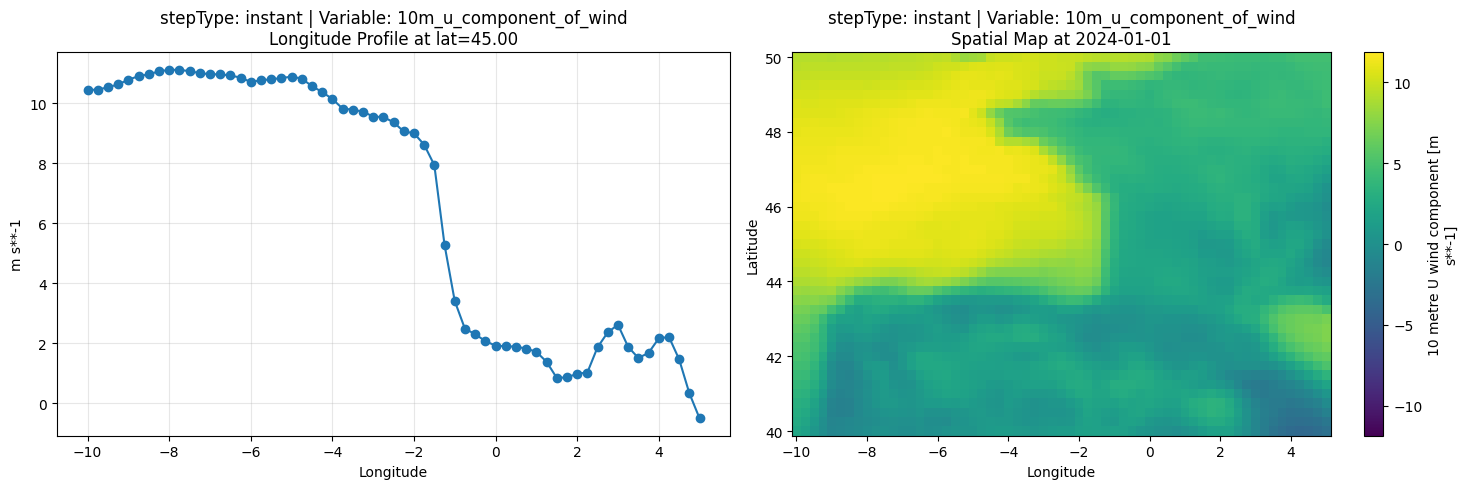

In [8]:
# Get the first variable name from the dataset
first_var = list(ds.data_vars)[0]
print(f"Plotting: {first_var}")

# Plot the first variable for the first time step
fig = plot_era5_variable(ds, first_var, time_index=0)
plt.show()

### Plot All Variables

Now let's create a comprehensive view of all variables for the first day:

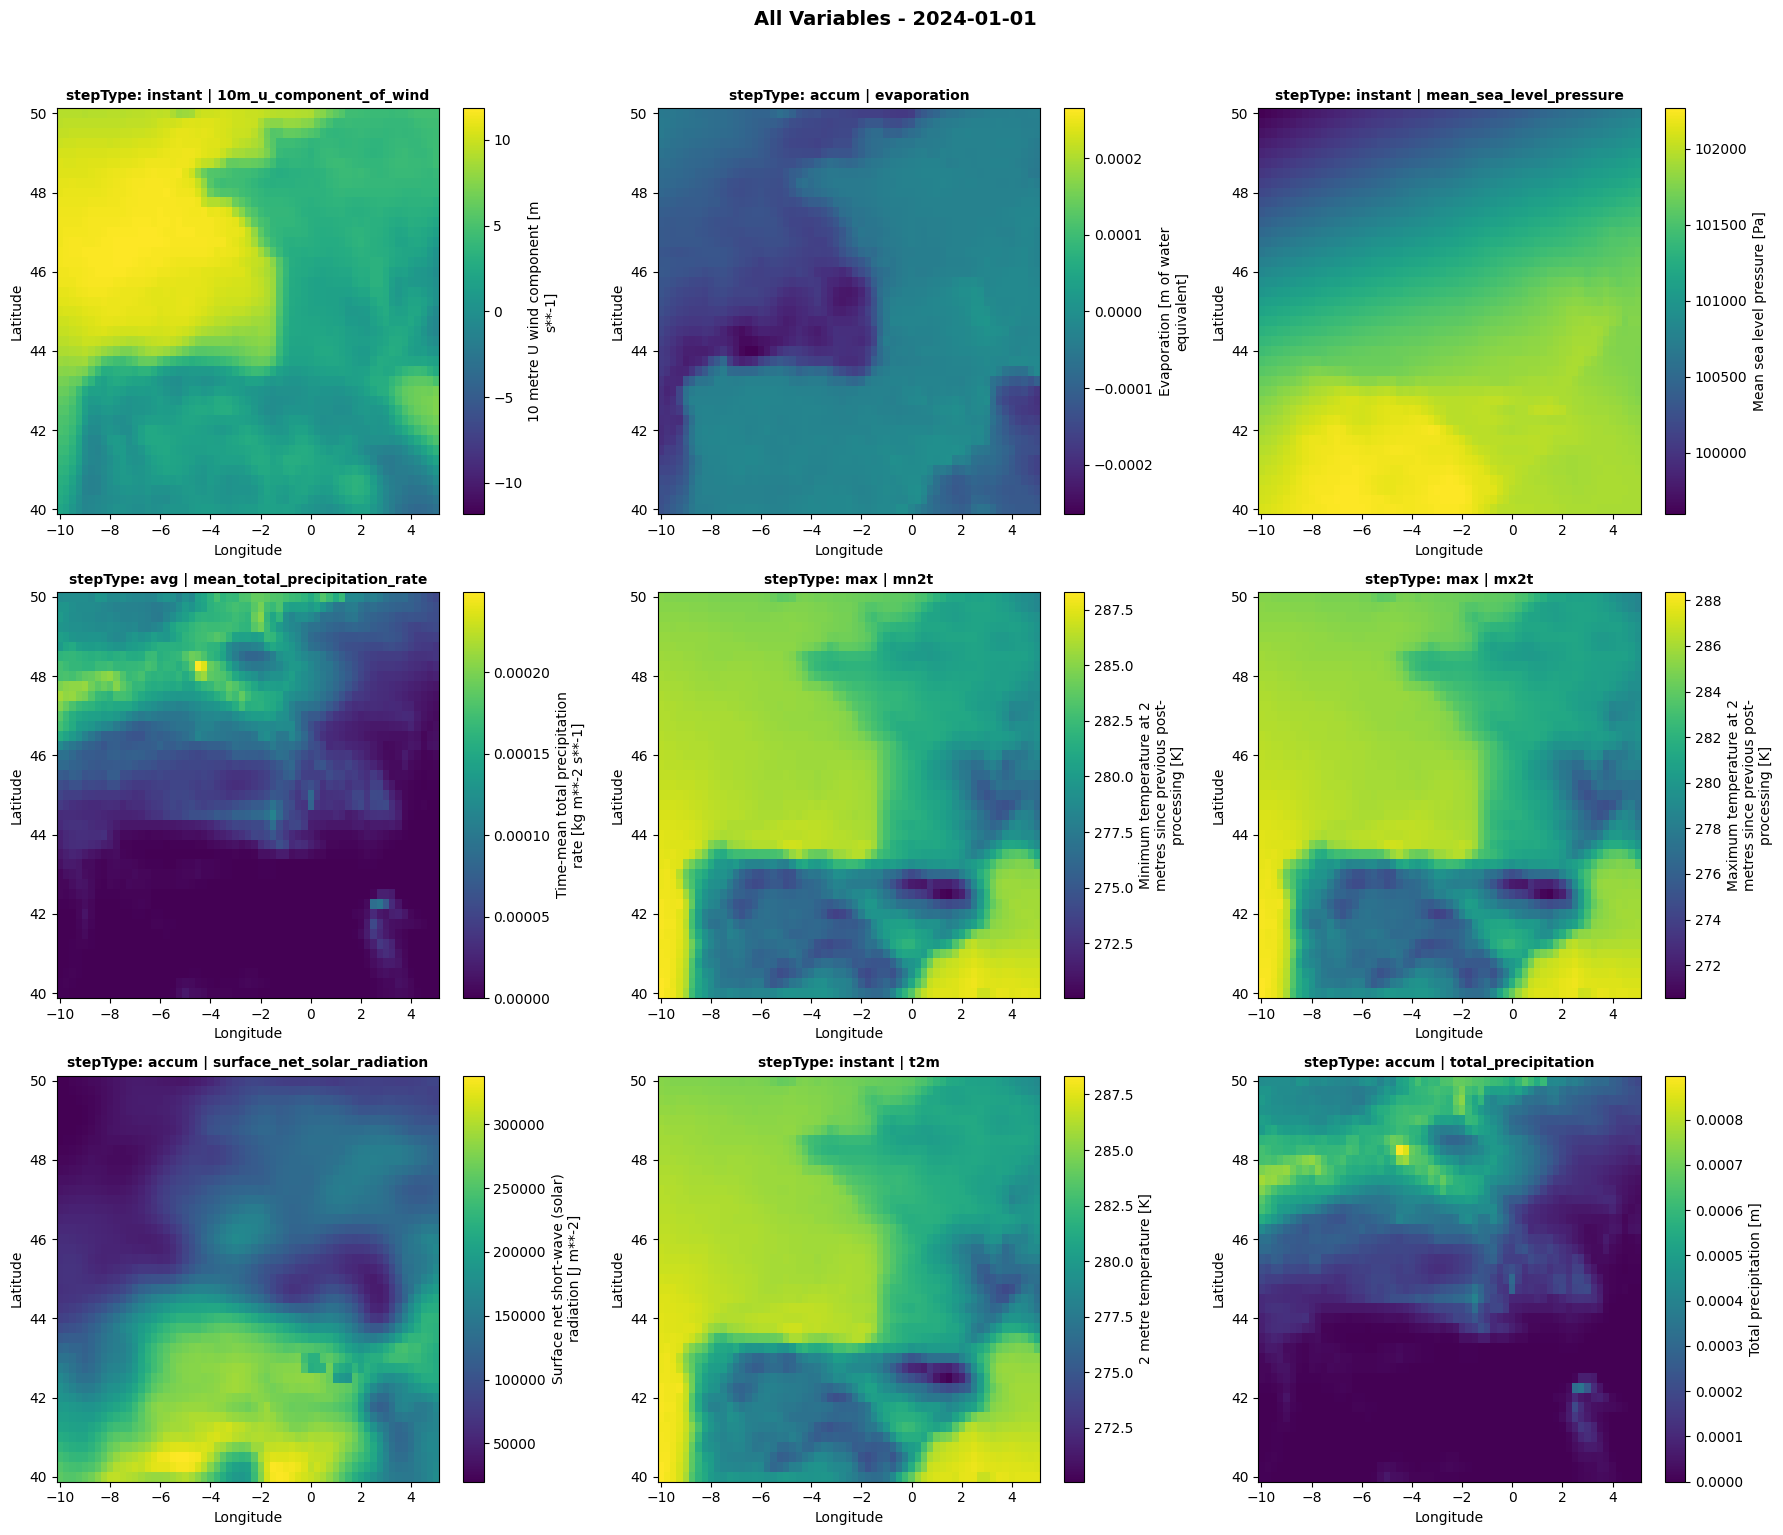

In [11]:
# Plot all variables for the first day
fig = plot_era5_variables_comparison(ds, time_index=0)
plt.show()